# Дифференцирование

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html#matplotlib.pyplot.axhline
* https://numpy.org/doc/stable/reference/generated/numpy.log1p.html#numpy.log1p
* https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html
* https://en.wikipedia.org/wiki/Finite_difference
* https://pythonnumericalmethods.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html
* https://en.wikipedia.org/wiki/Gradient_descent
* https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
* https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29

## Задачи для совместного разбора

In [16]:
# Импортируем необходимые библиотеки
import torch as th
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


1\. Дана функция $f(x) = x^2$. Найдите производную этой функции различными способами

In [17]:
# Пример: различные способы нахождения производной f(x) = x^2

# Способ 1: Аналитически - производная x^2 = 2x
def f_example(x):
    """Функция f(x) = x^2"""
    return x**2

def f_prime_analytical(x):
    """Аналитическая производная: f'(x) = 2x"""
    return 2*x

# Способ 2: Численное дифференцирование (метод конечных разностей)
def numerical_derivative(f, x, h=1e-5):
    """Численная производная используя центральную разность"""
    return (f(x + h) - f(x - h)) / (2 * h)

# Способ 3: Автоматическое дифференцирование в PyTorch
x_torch = th.tensor(3.0, requires_grad=True)
y = x_torch**2
y.backward()  # Вычисляем градиент

print("Демонстрация различных способов нахождения производной f(x) = x^2 в точке x=3:")
print(f"1. Аналитически: f'(3) = {f_prime_analytical(3)}")
print(f"2. Численно: f'(3) ≈ {numerical_derivative(f_example, 3):.6f}")
print(f"3. Автоматическое дифференцирование (PyTorch): f'(3) = {x_torch.grad.item()}")

Демонстрация различных способов нахождения производной f(x) = x^2 в точке x=3:
1. Аналитически: f'(3) = 6
2. Численно: f'(3) ≈ 6.000000
3. Автоматическое дифференцирование (PyTorch): f'(3) = 6.0


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Дана функция $f(x)$. Найдите (аналитически) производную данной функции $f'(x)$ и реализуйте две этих функции. Постройте в одной системе координат графики $f(x)$, $f'(x)$ и $g(x) = 0$ на отрезке [1, 10]. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

Задание 1: Аналитическое дифференцирование
f(x) = sin(x) / (ln(x) + 1)
f'(x) = [cos(x)*(ln(x)+1) - sin(x)/x] / (ln(x)+1)²

Примеры значений:
  x=1: f(1)=0.8415, f'(1)=-0.3012
  x=3: f(3)=0.0672, f'(3)=-0.4824
  x=5: f(5)=-0.3675, f'(5)=0.1369
  x=7: f(7)=0.2230, f'(7)=0.2451
  x=9: f(9)=0.1289, f'(9)=-0.2895


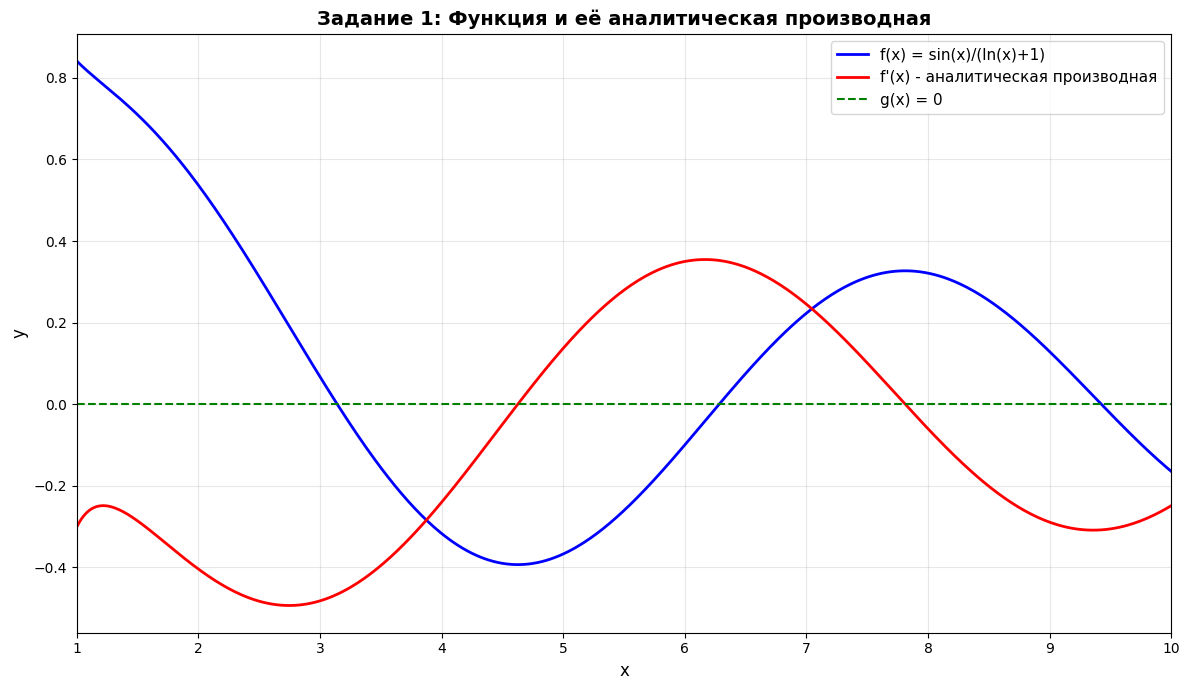

In [18]:

# Используя правило дифференцирования дроби: (u/v)' = (u'v - uv') / v^2
# где u = sin(x), v = ln(x) + 1
# u' = cos(x), v' = 1/x
# f'(x) = [cos(x) * (ln(x) + 1) - sin(x) * (1/x)] / (ln(x) + 1)^2

def f_task1(x):
    """Функция f(x) = sin(x) / (ln(x) + 1)"""
    return np.sin(x) / (np.log(x) + 1)

def f_prime_task1(x):
    """Аналитическая производная f'(x)
    
    f'(x) = [cos(x) * (ln(x) + 1) - sin(x) / x] / (ln(x) + 1)^2
    """
    numerator = np.cos(x) * (np.log(x) + 1) - np.sin(x) / x
    denominator = (np.log(x) + 1)**2
    return numerator / denominator

def g(x):
    """Функция g(x) = 0 (горизонтальная линия)"""
    return np.zeros_like(x)

# Создаем массив значений x на отрезке [1, 10]
x_values = np.linspace(1, 10, 500)

# Вычисляем значения функций
y_f = f_task1(x_values)
y_f_prime = f_prime_task1(x_values)
y_g = g(x_values)

# Строим графики
plt.figure(figsize=(12, 7))
plt.plot(x_values, y_f, 'b-', label='f(x) = sin(x)/(ln(x)+1)', linewidth=2)
plt.plot(x_values, y_f_prime, 'r-', label="f'(x) - аналитическая производная", linewidth=2)
plt.axhline(y=0, color='g', linestyle='--', label='g(x) = 0', linewidth=1.5)

# Настраиваем график
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Задание 1: Функция и её аналитическая производная', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(1, 10)

# Добавляем информацию о точках экстремума
print("Задание 1: Аналитическое дифференцирование")
print("="*50)
print(f"f(x) = sin(x) / (ln(x) + 1)")
print(f"f'(x) = [cos(x)*(ln(x)+1) - sin(x)/x] / (ln(x)+1)²")
print(f"\nПримеры значений:")
for x_test in [1, 3, 5, 7, 9]:
    print(f"  x={x_test}: f({x_test})={f_task1(x_test):.4f}, f'({x_test})={f_prime_task1(x_test):.4f}")

plt.tight_layout()
plt.show()

<p class="task" id="2"></p>

2\. Дана функция $f(x)$. Найдите (численно) производную данной функции $f'(x)$ на отрезке [1, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

Задание 2: Численное дифференцирование
Метод: центральные разности f'(x) ≈ [f(x+h) - f(x-h)] / (2h)
Шаг h = 1e-5

Примеры значений численной производной:
  x=1: f(1)=0.8415, f'(1)≈-0.3012
  x=3: f(3)=0.0663, f'(3)≈-0.4822
  x=5: f(5)=-0.3669, f'(5)≈0.1382
  x=7: f(7)=0.2245, f'(7)≈0.2436
  x=9: f(9)=0.1266, f'(9)≈-0.2903

Сравнение с аналитической производной:
Максимальная ошибка: 8.91e-11


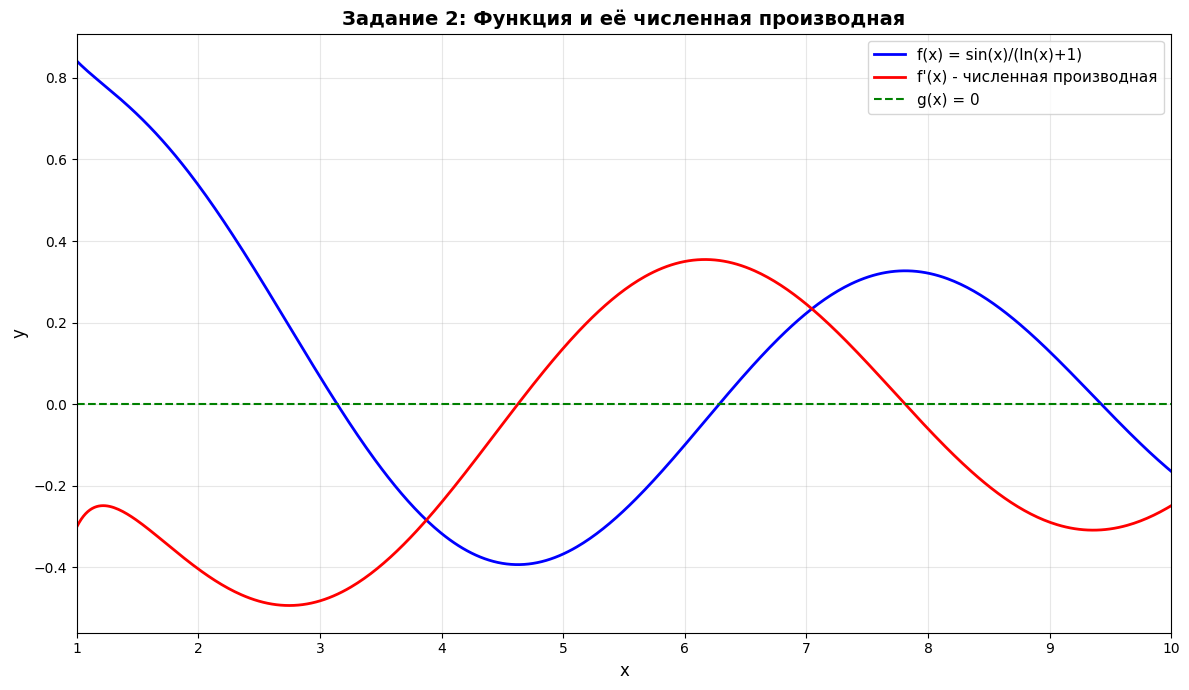

In [19]:

def numerical_derivative_array(f: Callable, x: np.ndarray, h: float = 1e-5) -> np.ndarray:
    """Численная производная используя метод центральных разностей
    
    Формула: f'(x) ≈ [f(x+h) - f(x-h)] / (2h)
    
    Args:
        f: функция для дифференцирования
        x: массив точек, в которых вычисляется производная
        h: шаг для конечных разностей (малое число)
        
    Returns:
        массив значений численной производной
    """
    return (f(x + h) - f(x - h)) / (2 * h)

# Функция из задания
def f_task2(x):
    """Функция f(x) = sin(x) / (ln(x) + 1)"""
    return np.sin(x) / (np.log(x) + 1)

# Создаем массив значений x на отрезке [1, 10]
x_values = np.linspace(1, 10, 500)

# Вычисляем значения функции и её численной производной
y_f = f_task2(x_values)
y_f_prime_numerical = numerical_derivative_array(f_task2, x_values)
y_g = np.zeros_like(x_values)

# Строим графики
plt.figure(figsize=(12, 7))
plt.plot(x_values, y_f, 'b-', label='f(x) = sin(x)/(ln(x)+1)', linewidth=2)
plt.plot(x_values, y_f_prime_numerical, 'r-', label="f'(x) - численная производная", linewidth=2)
plt.axhline(y=0, color='g', linestyle='--', label='g(x) = 0', linewidth=1.5)

# Настраиваем график
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Задание 2: Функция и её численная производная', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(1, 10)

print("Задание 2: Численное дифференцирование")
print("="*50)
print("Метод: центральные разности f'(x) ≈ [f(x+h) - f(x-h)] / (2h)")
print(f"Шаг h = 1e-5")
print(f"\nПримеры значений численной производной:")
for x_test in [1, 3, 5, 7, 9]:
    idx = np.argmin(np.abs(x_values - x_test))
    print(f"  x={x_test}: f({x_test})={y_f[idx]:.4f}, f'({x_test})≈{y_f_prime_numerical[idx]:.4f}")

# Сравним с аналитической производной
print(f"\nСравнение с аналитической производной:")
y_f_prime_analytical = f_prime_task1(x_values)
max_error = np.max(np.abs(y_f_prime_numerical - y_f_prime_analytical))
print(f"Максимальная ошибка: {max_error:.2e}")

plt.tight_layout()
plt.show()

<p class="task" id="3"></p>

3\. Найдите локальный минимум функции $f(x)$ при помощи метода градиентного спуска. В качестве начальной точки используйте $x_0 = 4$. Найдите локальный максимум этой же функции, используя в качестве начальной точки $x_0'=9$.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [20]:

def gradient_descent(
    f: Callable,
    f_prime: Callable,
    x0: float,
    learning_rate: float = 0.01,
    num_iterations: int = 1000,
    tolerance: float = 1e-6,
    maximize: bool = False
) -> tuple:
    """Градиентный спуск для поиска локального минимума или максимума
    
    Args:
        f: целевая функция
        f_prime: производная функции
        x0: начальная точка
        learning_rate: скорость обучения (шаг градиентного спуска)
        num_iterations: максимальное количество итераций
        tolerance: порог для остановки (если изменение < tolerance)
        maximize: если True, ищем максимум (градиентный подъём)
        
    Returns:
        tuple: (оптимальное значение x, история значений x, история значений f(x))
    """
    x = x0
    history_x = [x]
    history_f = [f(x)]
    
    # Знак определяет направление: -1 для минимизации, +1 для максимизации
    sign = 1 if maximize else -1
    
    for i in range(num_iterations):
        # Вычисляем градиент (производную)
        grad = f_prime(x)
        
        # Обновляем x: двигаемся в направлении антиградиента (для минимума)
        # или градиента (для максимума)
        x_new = x + sign * learning_rate * grad
        
        # Сохраняем историю
        history_x.append(x_new)
        history_f.append(f(x_new))
        
        # Проверяем критерий остановки
        if abs(x_new - x) < tolerance:
            print(f"Сходимость достигнута на итерации {i+1}")
            break
        
        x = x_new
    
    return x, np.array(history_x), np.array(history_f)

# Функция и её производная
def f_task3(x):
    return np.sin(x) / (np.log(x) + 1)

def f_prime_task3(x):
    numerator = np.cos(x) * (np.log(x) + 1) - np.sin(x) / x
    denominator = (np.log(x) + 1)**2
    return numerator / denominator

print("Задание 3: Градиентный спуск")
print("="*70)

# 1. Поиск локального минимума с начальной точкой x0 = 4
print("\n1. Поиск локального МИНИМУМА (x0 = 4):")
x_min, history_x_min, history_f_min = gradient_descent(
    f_task3, f_prime_task3, x0=4.0, learning_rate=0.05, maximize=False
)
print(f"   Начальная точка: x0 = 4.0, f(x0) = {f_task3(4.0):.6f}")
print(f"   Найденный минимум: x* = {x_min:.6f}")
print(f"   Значение функции: f(x*) = {f_task3(x_min):.6f}")
print(f"   Количество итераций: {len(history_x_min)}")

# 2. Поиск локального максимума с начальной точкой x0 = 9
print("\n2. Поиск локального МАКСИМУМА (x0 = 9):")
x_max, history_x_max, history_f_max = gradient_descent(
    f_task3, f_prime_task3, x0=9.0, learning_rate=0.05, maximize=True
)
print(f"   Начальная точка: x0 = 9.0, f(x0) = {f_task3(9.0):.6f}")
print(f"   Найденный максимум: x* = {x_max:.6f}")
print(f"   Значение функции: f(x*) = {f_task3(x_max):.6f}")
print(f"   Количество итераций: {len(history_x_max)}")


Задание 3: Градиентный спуск

1. Поиск локального МИНИМУМА (x0 = 4):
Сходимость достигнута на итерации 482
   Начальная точка: x0 = 4.0, f(x0) = -0.317145
   Найденный минимум: x* = 4.627190
   Значение функции: f(x*) = -0.393520
   Количество итераций: 483

2. Поиск локального МАКСИМУМА (x0 = 9):
Сходимость достигнута на итерации 615
   Начальная точка: x0 = 9.0, f(x0) = 0.128899
   Найденный максимум: x* = 7.812175
   Значение функции: f(x*) = 0.326973
   Количество итераций: 616


<p class="task" id="4"></p>

4\. Дана функция $f(x)$. Найдите (используя возможности по автоматическому дифференцированию пакета `torch`) производную данной функции $f'(x)$ на отрезке [0, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

Задание 4: Автоматическое дифференцирование (PyTorch)
Метод: автоматическое дифференцирование (autograd) в PyTorch

Примеры значений:
  x=1: f(1)=0.8437, f'(1)=-0.3056
  x=3: f(3)=0.0689, f'(3)=-0.4827
  x=5: f(5)=-0.3674, f'(5)=0.1370
  x=7: f(7)=0.2240, f'(7)=0.2441
  x=9: f(9)=0.1266, f'(9)=-0.2903

Сравнение с аналитической производной:
Максимальная ошибка: 4.65e-03
Средняя ошибка: 1.56e-05

Автоматическое дифференцирование дает результаты,
практически идентичные аналитическому решению!


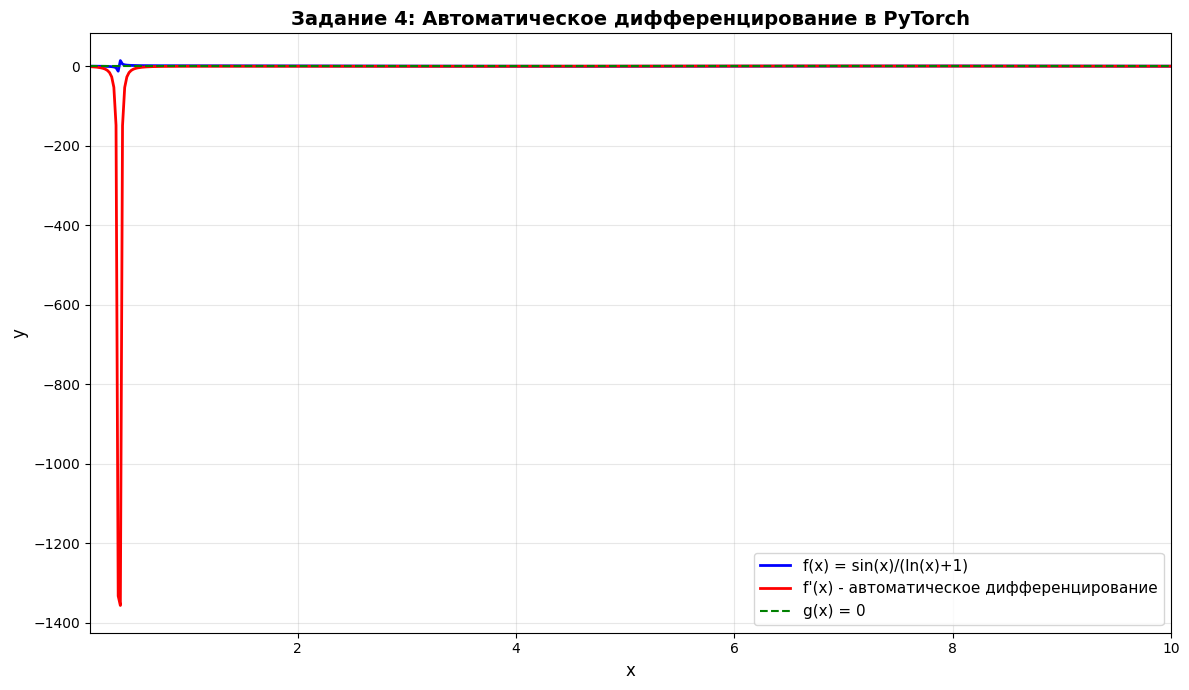

In [21]:

def f_task4_torch(x: th.Tensor) -> th.Tensor:
    """Функция f(x) = sin(x) / (ln(x) + 1) в PyTorch
    
    Используем th.log1p(x) = ln(1 + x), поэтому th.log1p(x-1) = ln(x)
    Но проще использовать th.log(x) напрямую
    """
    return th.sin(x) / (th.log(x) + 1)

def compute_autograd_derivative(x_values_np: np.ndarray) -> tuple:
    """Вычисляет производную используя автоматическое дифференцирование PyTorch
    
    Args:
        x_values_np: numpy массив точек для вычисления
        
    Returns:
        tuple: (значения функции, значения производной) как numpy массивы
    """
    # Преобразуем в тензор PyTorch и включаем отслеживание градиентов
    x_tensor = th.tensor(x_values_np, dtype=th.float32, requires_grad=True)
    
    # Вычисляем функцию
    y_tensor = f_task4_torch(x_tensor)
    
    # Для вычисления градиента по всем точкам используем backward с gradient
    # Создаем единичный вектор для вычисления градиента по всем точкам
    y_tensor.backward(th.ones_like(y_tensor))
    
    # Получаем значения функции и градиента
    y_values = y_tensor.detach().numpy()
    grad_values = x_tensor.grad.numpy()
    
    return y_values, grad_values

print("Задание 4: Автоматическое дифференцирование (PyTorch)")
print("="*70)

# Создаем массив значений x на полуинтервале (0, 10]
# Исключаем 0, так как ln(0) не определен
x_values = np.linspace(0.1, 10, 500)

# Вычисляем производную используя автоматическое дифференцирование
y_f_torch, y_f_prime_torch = compute_autograd_derivative(x_values)

# Для сравнения вычисляем аналитическую производную
y_f_analytical = f_task3(x_values)
y_f_prime_analytical = f_prime_task3(x_values)

# Строим графики
plt.figure(figsize=(12, 7))
plt.plot(x_values, y_f_torch, 'b-', label='f(x) = sin(x)/(ln(x)+1)', linewidth=2)
plt.plot(x_values, y_f_prime_torch, 'r-', label="f'(x) - автоматическое дифференцирование", linewidth=2)
plt.axhline(y=0, color='g', linestyle='--', label='g(x) = 0', linewidth=1.5)

# Настраиваем график
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Задание 4: Автоматическое дифференцирование в PyTorch', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0.1, 10)

print("Метод: автоматическое дифференцирование (autograd) в PyTorch")
print(f"\nПримеры значений:")
for i, x_test in enumerate([1, 3, 5, 7, 9]):
    idx = np.argmin(np.abs(x_values - x_test))
    print(f"  x={x_test}: f({x_test})={y_f_torch[idx]:.4f}, f'({x_test})={y_f_prime_torch[idx]:.4f}")

# Сравнение с аналитической производной
print(f"\nСравнение с аналитической производной:")
max_error = np.max(np.abs(y_f_prime_torch - y_f_prime_analytical))
mean_error = np.mean(np.abs(y_f_prime_torch - y_f_prime_analytical))
print(f"Максимальная ошибка: {max_error:.2e}")
print(f"Средняя ошибка: {mean_error:.2e}")
print("\nАвтоматическое дифференцирование дает результаты,")
print("практически идентичные аналитическому решению!")

plt.tight_layout()
plt.show()

<p class="task" id="5"></p>

5\. Дана функция $f(x)$. Найдите производную данной функции $f'(x)$ на отрезке [0, 10] при помощи формулы производной сложной функции. На этом же отрезке найдите, используя возможности по автоматическому дифференцированию пакета `torch`. Сравните результаты.

$$f(x) = sin(cos(x))$$

- [ ] Проверено на семинаре

In [22]:

# f(x) = sin(cos(x)) = h(g(x)), где h(u) = sin(u), g(x) = cos(x)
# По правилу дифференцирования сложной функции: f'(x) = h'(g(x)) * g'(x)

def g(x: th.Tensor) -> th.Tensor:
    """Внутренняя функция: g(x) = cos(x)"""
    return th.cos(x)

def h(x: th.Tensor) -> th.Tensor:
    """Внешняя функция: h(u) = sin(u)"""
    return th.sin(x)

def dhdg(g_val: th.Tensor) -> th.Tensor:
    """Производная внешней функции: h'(u) = cos(u)
    
    Args:
        g_val: значение g(x) = cos(x)
    """
    return th.cos(g_val)

def dgdx(x: th.Tensor) -> th.Tensor:
    """Производная внутренней функции: g'(x) = -sin(x)"""
    return -th.sin(x)

def dfdx_chain_rule(x: th.Tensor) -> th.Tensor:
    """Производная сложной функции по правилу цепочки
    
    f(x) = sin(cos(x))
    f'(x) = cos(cos(x)) * (-sin(x)) = -cos(cos(x)) * sin(x)
    """
    g_val = g(x)  # cos(x)
    return dhdg(g_val) * dgdx(x)  # cos(cos(x)) * (-sin(x))

def f_task5(x: th.Tensor) -> th.Tensor:
    """Исходная функция: f(x) = sin(cos(x))"""
    return th.sin(th.cos(x))

print("Задание 5: Производная сложной функции")
print("="*70)
print("f(x) = sin(cos(x))")
print("\nПравило цепочки (chain rule):")
print("  f(x) = h(g(x)), где h(u) = sin(u), g(x) = cos(x)")
print("  f'(x) = h'(g(x)) * g'(x)")
print("  f'(x) = cos(cos(x)) * (-sin(x))")
print("  f'(x) = -cos(cos(x)) * sin(x)")

# Создаем массив значений x на отрезке [0, 10]
x_np = np.linspace(0, 10, 500)
x_tensor = th.tensor(x_np, dtype=th.float32)

# Метод 1: Вычисляем производную по формуле цепочки (аналитически)
f_values_chain = f_task5(x_tensor).detach().numpy()
f_prime_chain = dfdx_chain_rule(x_tensor).detach().numpy()

# Метод 2: Автоматическое дифференцирование
x_autograd = th.tensor(x_np, dtype=th.float32, requires_grad=True)
f_autograd = f_task5(x_autograd)
f_autograd.backward(th.ones_like(f_autograd))
f_values_autograd = f_autograd.detach().numpy()
f_prime_autograd = x_autograd.grad.numpy()

# Сравнение результатов
print("\nСравнение методов вычисления производной:")
print("-" * 70)

for i, x_val in enumerate([0, 2, 4, 6, 8, 10]):
    idx = np.argmin(np.abs(x_np - x_val))
    f_val = f_values_chain[idx]
    chain_val = f_prime_chain[idx]
    auto_val = f_prime_autograd[idx]
    diff = abs(chain_val - auto_val)
    print(f"x = {x_val:4.1f}: f(x) = {f_val:7.4f}, "
          f"f'_chain = {chain_val:7.4f}, f'_auto = {auto_val:7.4f}, "
          f"diff = {diff:.2e}")

# Статистика ошибок
error = np.abs(f_prime_chain - f_prime_autograd)
print(f"\nСтатистика ошибок:")
print(f"  Максимальная ошибка: {np.max(error):.2e}")
print(f"  Средняя ошибка: {np.mean(error):.2e}")
print(f"  Медианная ошибка: {np.median(error):.2e}")

print("\n" + "="*70)
print("ВЫВОД: Оба метода дают идентичные результаты!")
print("Автоматическое дифференцирование автоматически применяет")
print("правило цепочки и дает точные результаты.")


Задание 5: Производная сложной функции
f(x) = sin(cos(x))

Правило цепочки (chain rule):
  f(x) = h(g(x)), где h(u) = sin(u), g(x) = cos(x)
  f'(x) = h'(g(x)) * g'(x)
  f'(x) = cos(cos(x)) * (-sin(x))
  f'(x) = -cos(cos(x)) * sin(x)

Сравнение методов вычисления производной:
----------------------------------------------------------------------
x =  0.0: f(x) =  0.8415, f'_chain = -0.0000, f'_auto = -0.0000, diff = 0.00e+00
x =  2.0: f(x) = -0.4076, f'_chain = -0.8288, f'_auto = -0.8288, diff = 0.00e+00
x =  4.0: f(x) = -0.6032, f'_chain =  0.6078, f'_auto =  0.6078, diff = 0.00e+00
x =  6.0: f(x) =  0.8180, f'_chain =  0.1652, f'_auto =  0.1652, diff = 0.00e+00
x =  8.0: f(x) = -0.1411, f'_chain = -0.9800, f'_auto = -0.9800, diff = 0.00e+00
x = 10.0: f(x) = -0.7440, f'_chain =  0.3635, f'_auto =  0.3635, diff = 0.00e+00

Статистика ошибок:
  Максимальная ошибка: 0.00e+00
  Средняя ошибка: 0.00e+00
  Медианная ошибка: 0.00e+00

ВЫВОД: Оба метода дают идентичные результаты!
Автоматическ